In [4]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns
import pandas as pd
from scipy.optimize import curve_fit

In [38]:
def calculate_bending_modulus(structure_file, lipid_selection, cutoff):
    u = mda.Universe(structure_file)
    protein = "protein and name CA"

    residue_indices = []
    APL_values = []

    for residue in u.select_atoms(protein).residues:
        residue_indices.append(residue.resid)
        lipid_atoms = u.select_atoms(f"resname {lipid_selection} and around {cutoff} resid {residue.resid}")
        num_lipids = len(lipid_atoms.residues)
        
        box_area = u.dimensions[0] * u.dimensions[1]
        APL = box_area / num_lipids
        APL_values.append(APL)

    mean_APL = np.mean(APL_values)
    
    bending_modulus = (1 / (2 * mean_APL)) * np.var(APL_values)
    
    return mean_APL, bending_modulus

In [40]:
structure_file = "2N3X+POPC.gro"
lipid_selection = "POPC"
cutoff = 10.0

mean_APL, bending_modulus = calculate_bending_modulus(structure_file, lipid_selection, cutoff)

print(f"Average Area per Lipid: {mean_APL:.2f} A^2")
print(f"Bending Modulus (Kc): {bending_modulus:.2f} kJ/mol")

Average Area per Lipid: 3175.60 A^2
Bending Modulus (Kc): 182.77 kJ/mol


In [41]:
structure_file = "2N3X+POPC+CHOL.gro"
lipid_selection = "POPC or resname CHOL"
cutoff = 10.0

mean_APL, bending_modulus = calculate_bending_modulus(structure_file, lipid_selection, cutoff)

print(f"Average Area per Lipid: {mean_APL:.2f} A^2")
print(f"Bending Modulus (Kc): {bending_modulus:.2f} kJ/mol")

Average Area per Lipid: 4363.76 A^2
Bending Modulus (Kc): 235.24 kJ/mol


In [55]:
structure_file = "2N3X+POPS.gro"
lipid_selection = "POPS"
cutoff = 10.0

mean_APL, bending_modulus = calculate_bending_modulus(structure_file, lipid_selection, cutoff)

print(f"Average Area per Lipid: {mean_APL:.2f} A^2")
print(f"Bending Modulus (Kc): {bending_modulus:.2f} kJ/mol")

Average Area per Lipid: 2542.04 A^2
Bending Modulus (Kc): 93.67 kJ/mol


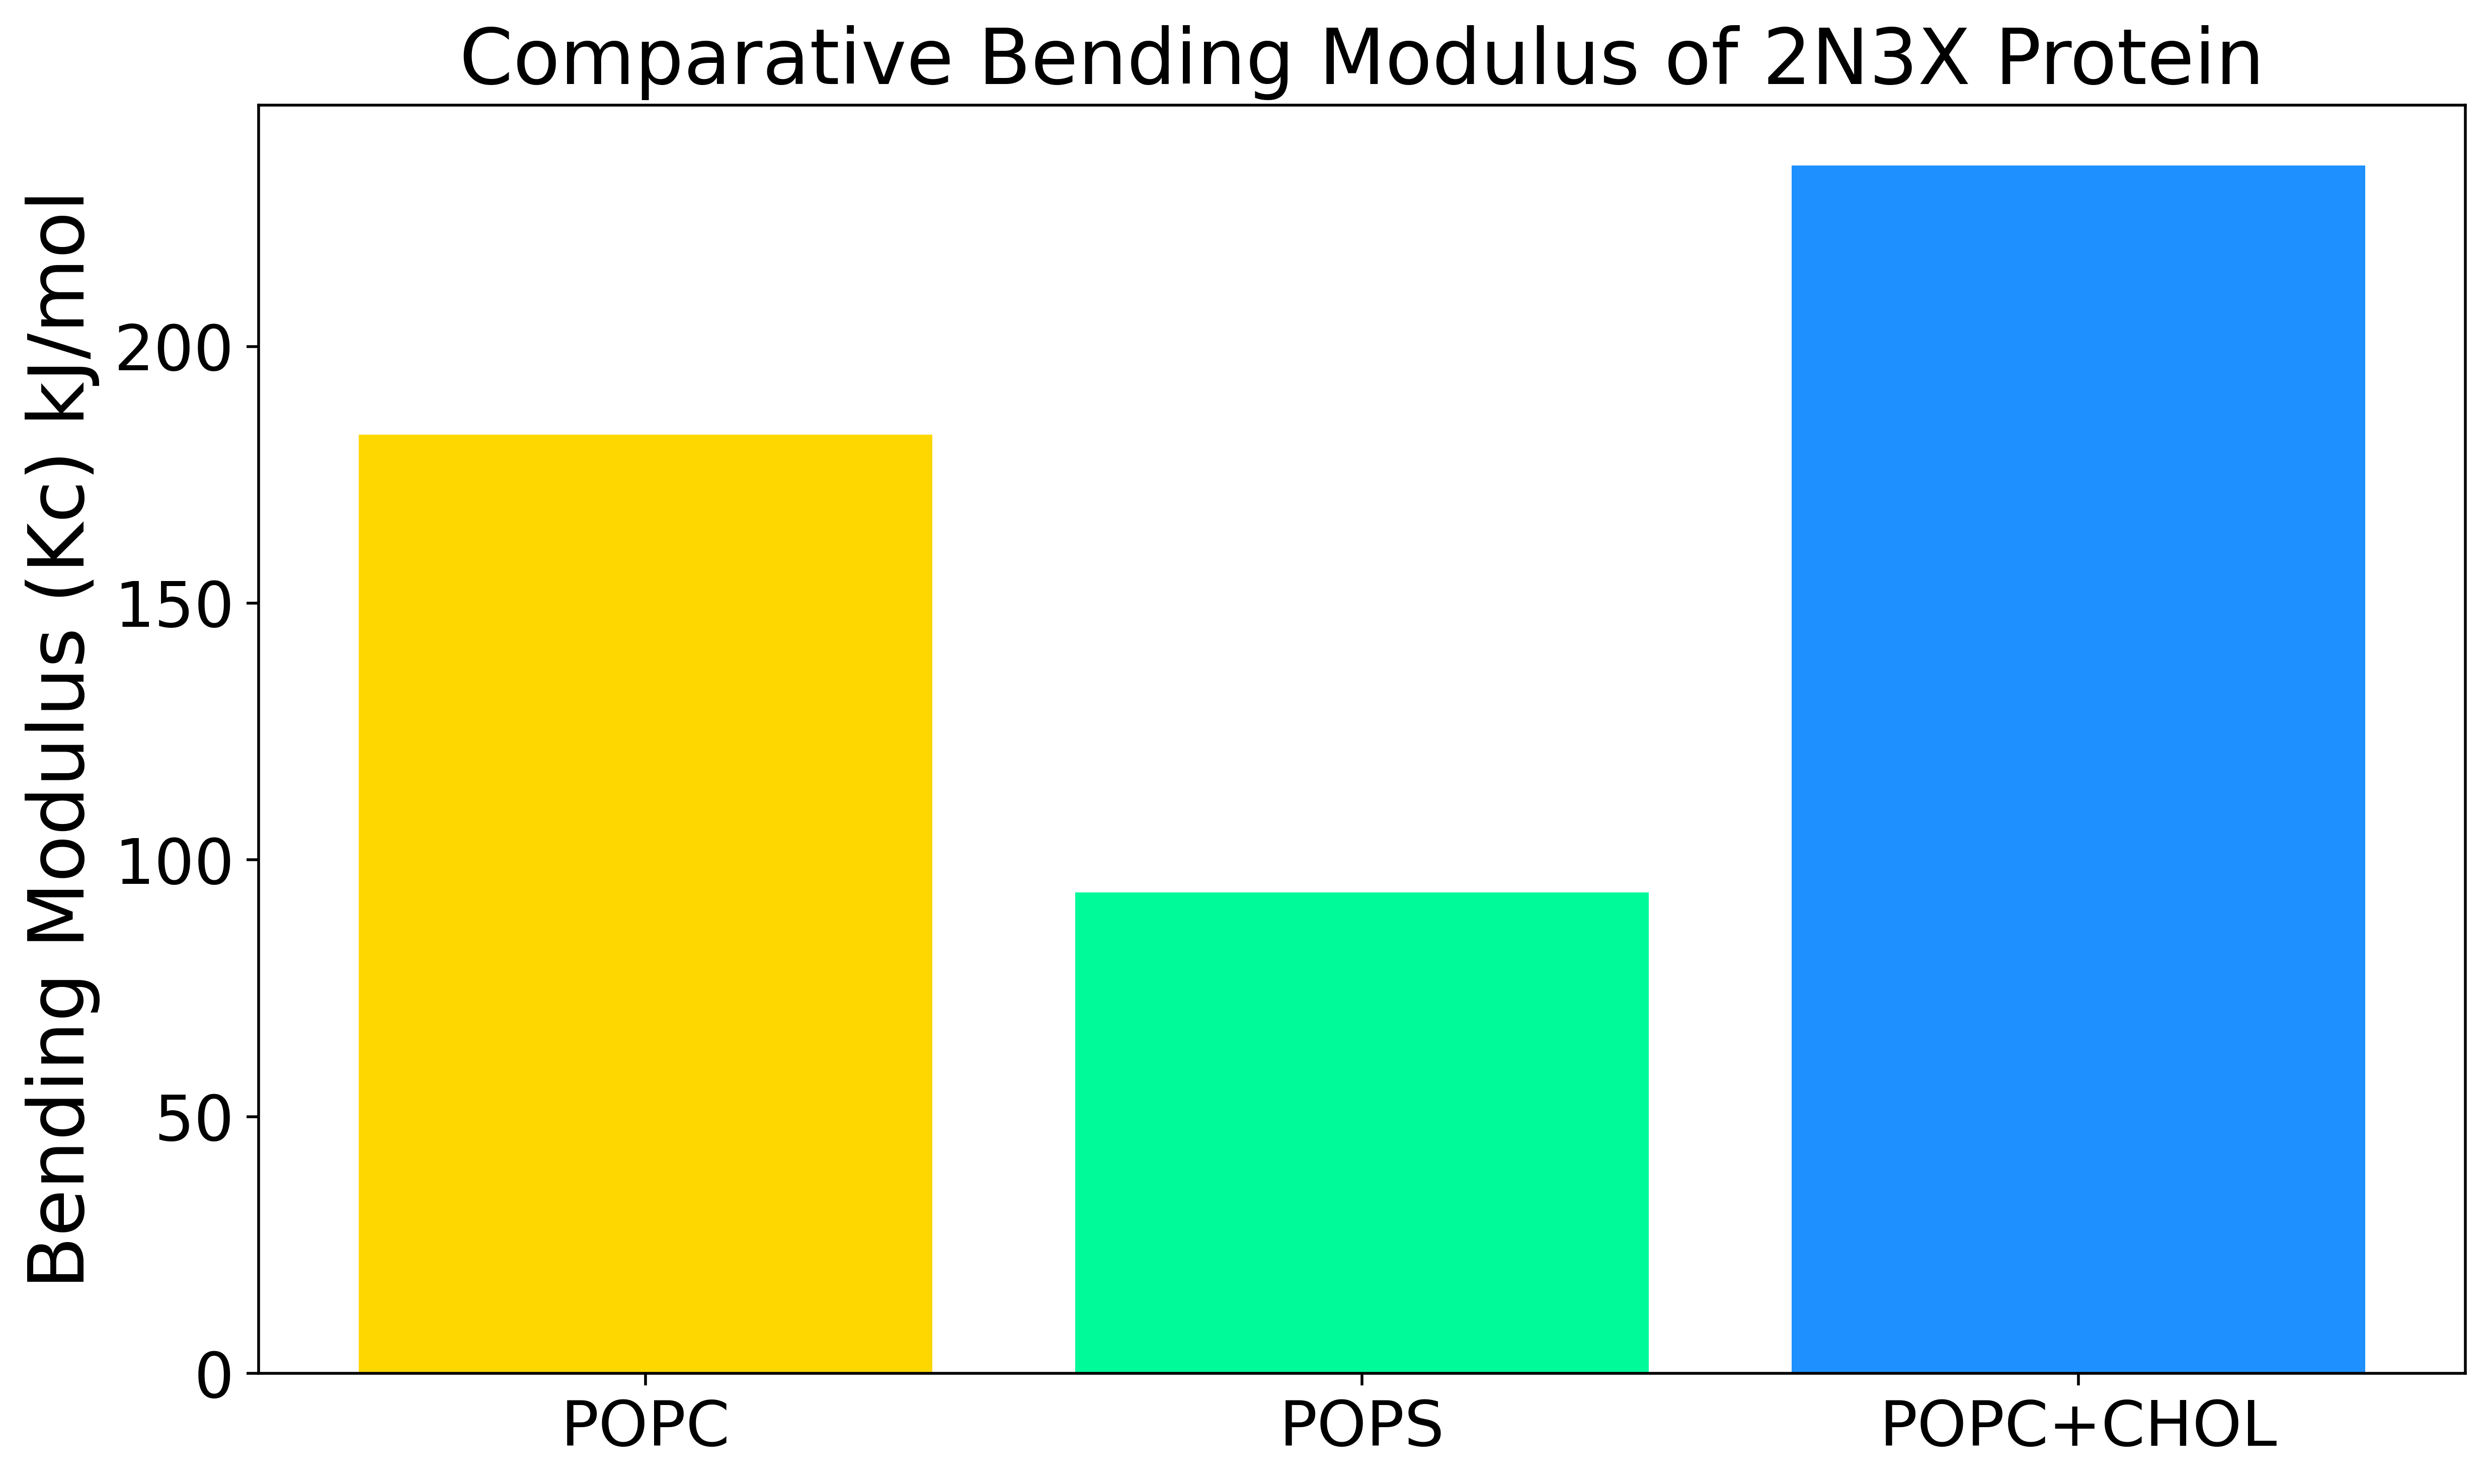

In [64]:

values_system1 = 182.77 
values_system2 = 93.67
values_system3 = 235.24 

fig, ax = plt.subplots(figsize=(10, 6),dpi=500)

ax.bar([1,2,3],[values_system1,values_system2 ,values_system3], tick_label=["POPC","POPS","POPC+CHOL"],color=['gold', 'mediumspringgreen','dodgerblue'])

ax.set_ylabel("Bending Modulus (Kc) kJ/mol",fontsize=22)
ax.set_title("Comparative Bending Modulus of 2N3X Protein",fontsize=22)
plt.tick_params(axis = "both",which = "major",labelsize=18)
plt.tight_layout()
plt.savefig("2N3X_bending_modulas.png",dpi=500)
plt.show()

In [4]:
def calculate_t_vector(lipid_atoms):
    phosphate = lipid_atoms.select_atoms("name P")
    c2 = lipid_atoms.select_atoms("name C2")
    terminal_carbons = lipid_atoms.select_atoms("name C31 or name C32 or name C33")
    midpoint = (phosphate.positions + c2.positions) / 2
    center_of_mass = terminal_carbons.center_of_mass()
    t_vector = center_of_mass - midpoint
    return t_vector / np.linalg.norm(t_vector)

In [7]:
u = mda.Universe("2N3X+POPC.gro","2N3X+POPC.xtc")

In [6]:
def calculate_t_vector(lipid_atoms):
    phosphate = lipid_atoms.select_atoms("name P")
    c2 = lipid_atoms.select_atoms("name C2")
    terminal_carbons = lipid_atoms.select_atoms("name C216 or name C217 or name C218 or name C314 or name C315 or name C316")
    midpoint = (phosphate.positions + c2.positions) / 2
    center_of_mass = terminal_carbons.center_of_mass()
    t_vector = center_of_mass - midpoint
    return t_vector / np.linalg.norm(t_vector)

def calculate_angle(v1, v2):
    dot_product = np.dot(v1, v2)
    angle = np.arccos(dot_product) * (180.0 / np.pi)
    return angle

def select_lipids_with_small_angle(structure_file, trajectory_file, angle_threshold=10.0):
    u = mda.Universe(structure_file, trajectory_file)
    
    lipid_selection = "resname POPC"
    lipid_atoms = u.select_atoms(lipid_selection)
    n_lipids = len(lipid_atoms.residues)
    
    selected_lipids = []
    
    for ts in u.trajectory:
        selected_residues = []
        t_vectors = []
        for i in range(n_lipids):
            lipid_atoms_i = lipid_atoms.residues[i].atoms
            t_vectors.append(calculate_t_vector(lipid_atoms_i))
        
        z_axis = np.array([0.0, 0.0, 1.0])
        for i in range(n_lipids):
            angle = calculate_angle(t_vectors[i], z_axis)
            if angle < angle_threshold:
                selected_residues.append(lipid_atoms.residues[i].resid)
        
        selected_lipids.append(selected_residues)
    
    return selected_lipids

In [7]:
structure_file = "2N3X+POPC.gro"
trajectory_file = "2N3X+POPC.xtc"
selected_lipids = select_lipids_with_small_angle(structure_file, trajectory_file)

In [1]:
for t, lipids in enumerate(selected_lipids):
    print(f"Time step {t+1}: Selected Lipid Residues - {lipids}")

NameError: name 'selected_lipids' is not defined

In [2]:
print(selected_lipids)

NameError: name 'selected_lipids' is not defined

In [9]:
def calculate_splay_angle(selected_lipids):
    splay_angles = []
    for x in selected_lipids:
        number = len(x)
        
        if number >= 2:
            t1_vectors = []
            
            for y in x:
                lipid_atoms_resid = u.select_atoms(f"resid {y}") 
                t1 = calculate_t_vector(lipid_atoms_resid)
                t1_vectors.append(t1)  
                
            for i in range(number):
                for j in range(i+1, number):
                    splay_angle = calculate_angle(t1_vectors[i][0], t1_vectors[j][0])
                    #if 0<= splay_angle <= 90:
                    splay_angles.append(splay_angle)
                    
    return splay_angles

splay_angles = calculate_splay_angle(selected_lipids)

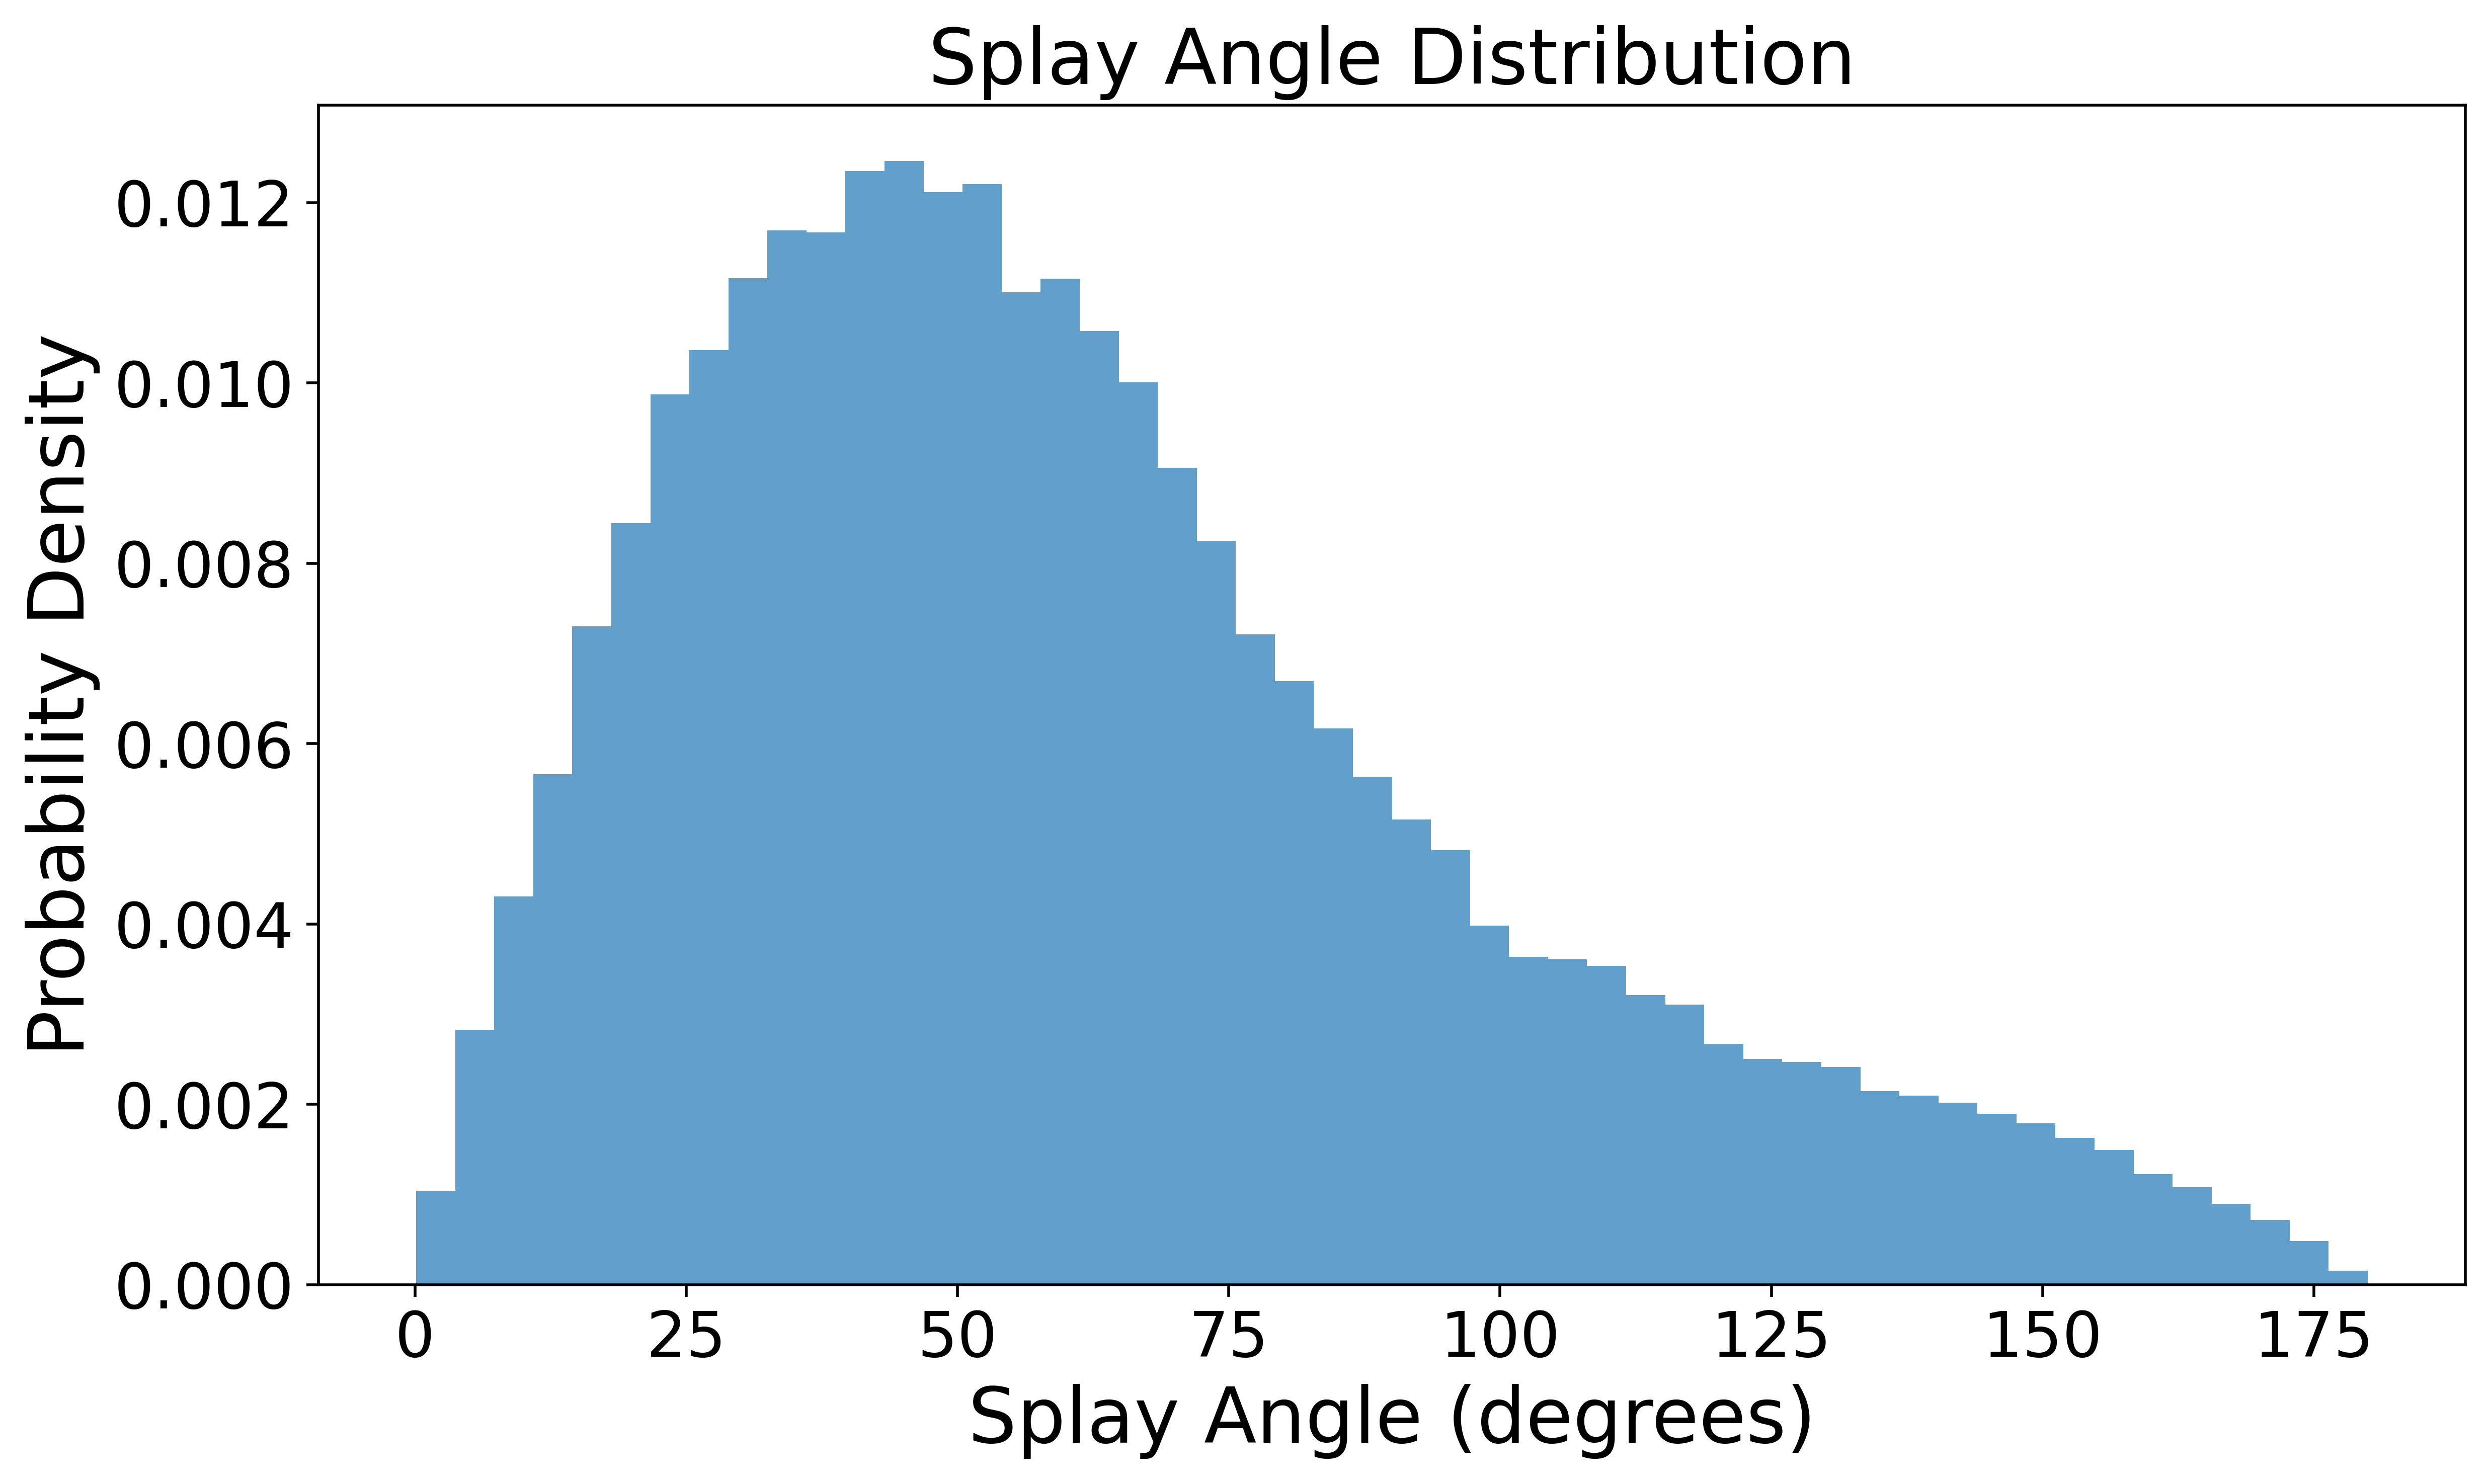

In [67]:
plt.figure(figsize=(10,6),dpi=500)
plt.hist(splay_angles, bins=50, density=True, alpha=0.7)
plt.xlabel('Splay Angle (degrees)',fontsize=22)
plt.ylabel('Probability Density',fontsize=22)
plt.tick_params(axis = "both",which = "major",labelsize=18)
plt.title('Splay Angle Distribution',fontsize=22)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import gaussian_kde
kde = gaussian_kde(splay_angles)
x_vals = np.linspace(min(splay_angles), max(splay_angles), 100000)
y_vals = kde(x_vals)

plt.figure(figsize=(10,6),dpi=500)
plt.plot(x_vals, y_vals, linewidth=2)
plt.xlabel('Splay Angle (degrees)',fontsize=22)
plt.ylabel('Probability Density',fontsize=22)
plt.tick_params(axis = "both",which = "major",labelsize=18)
plt.title('Splay Angle Distribution',fontsize=22)
plt.tight_layout()
plt.show()

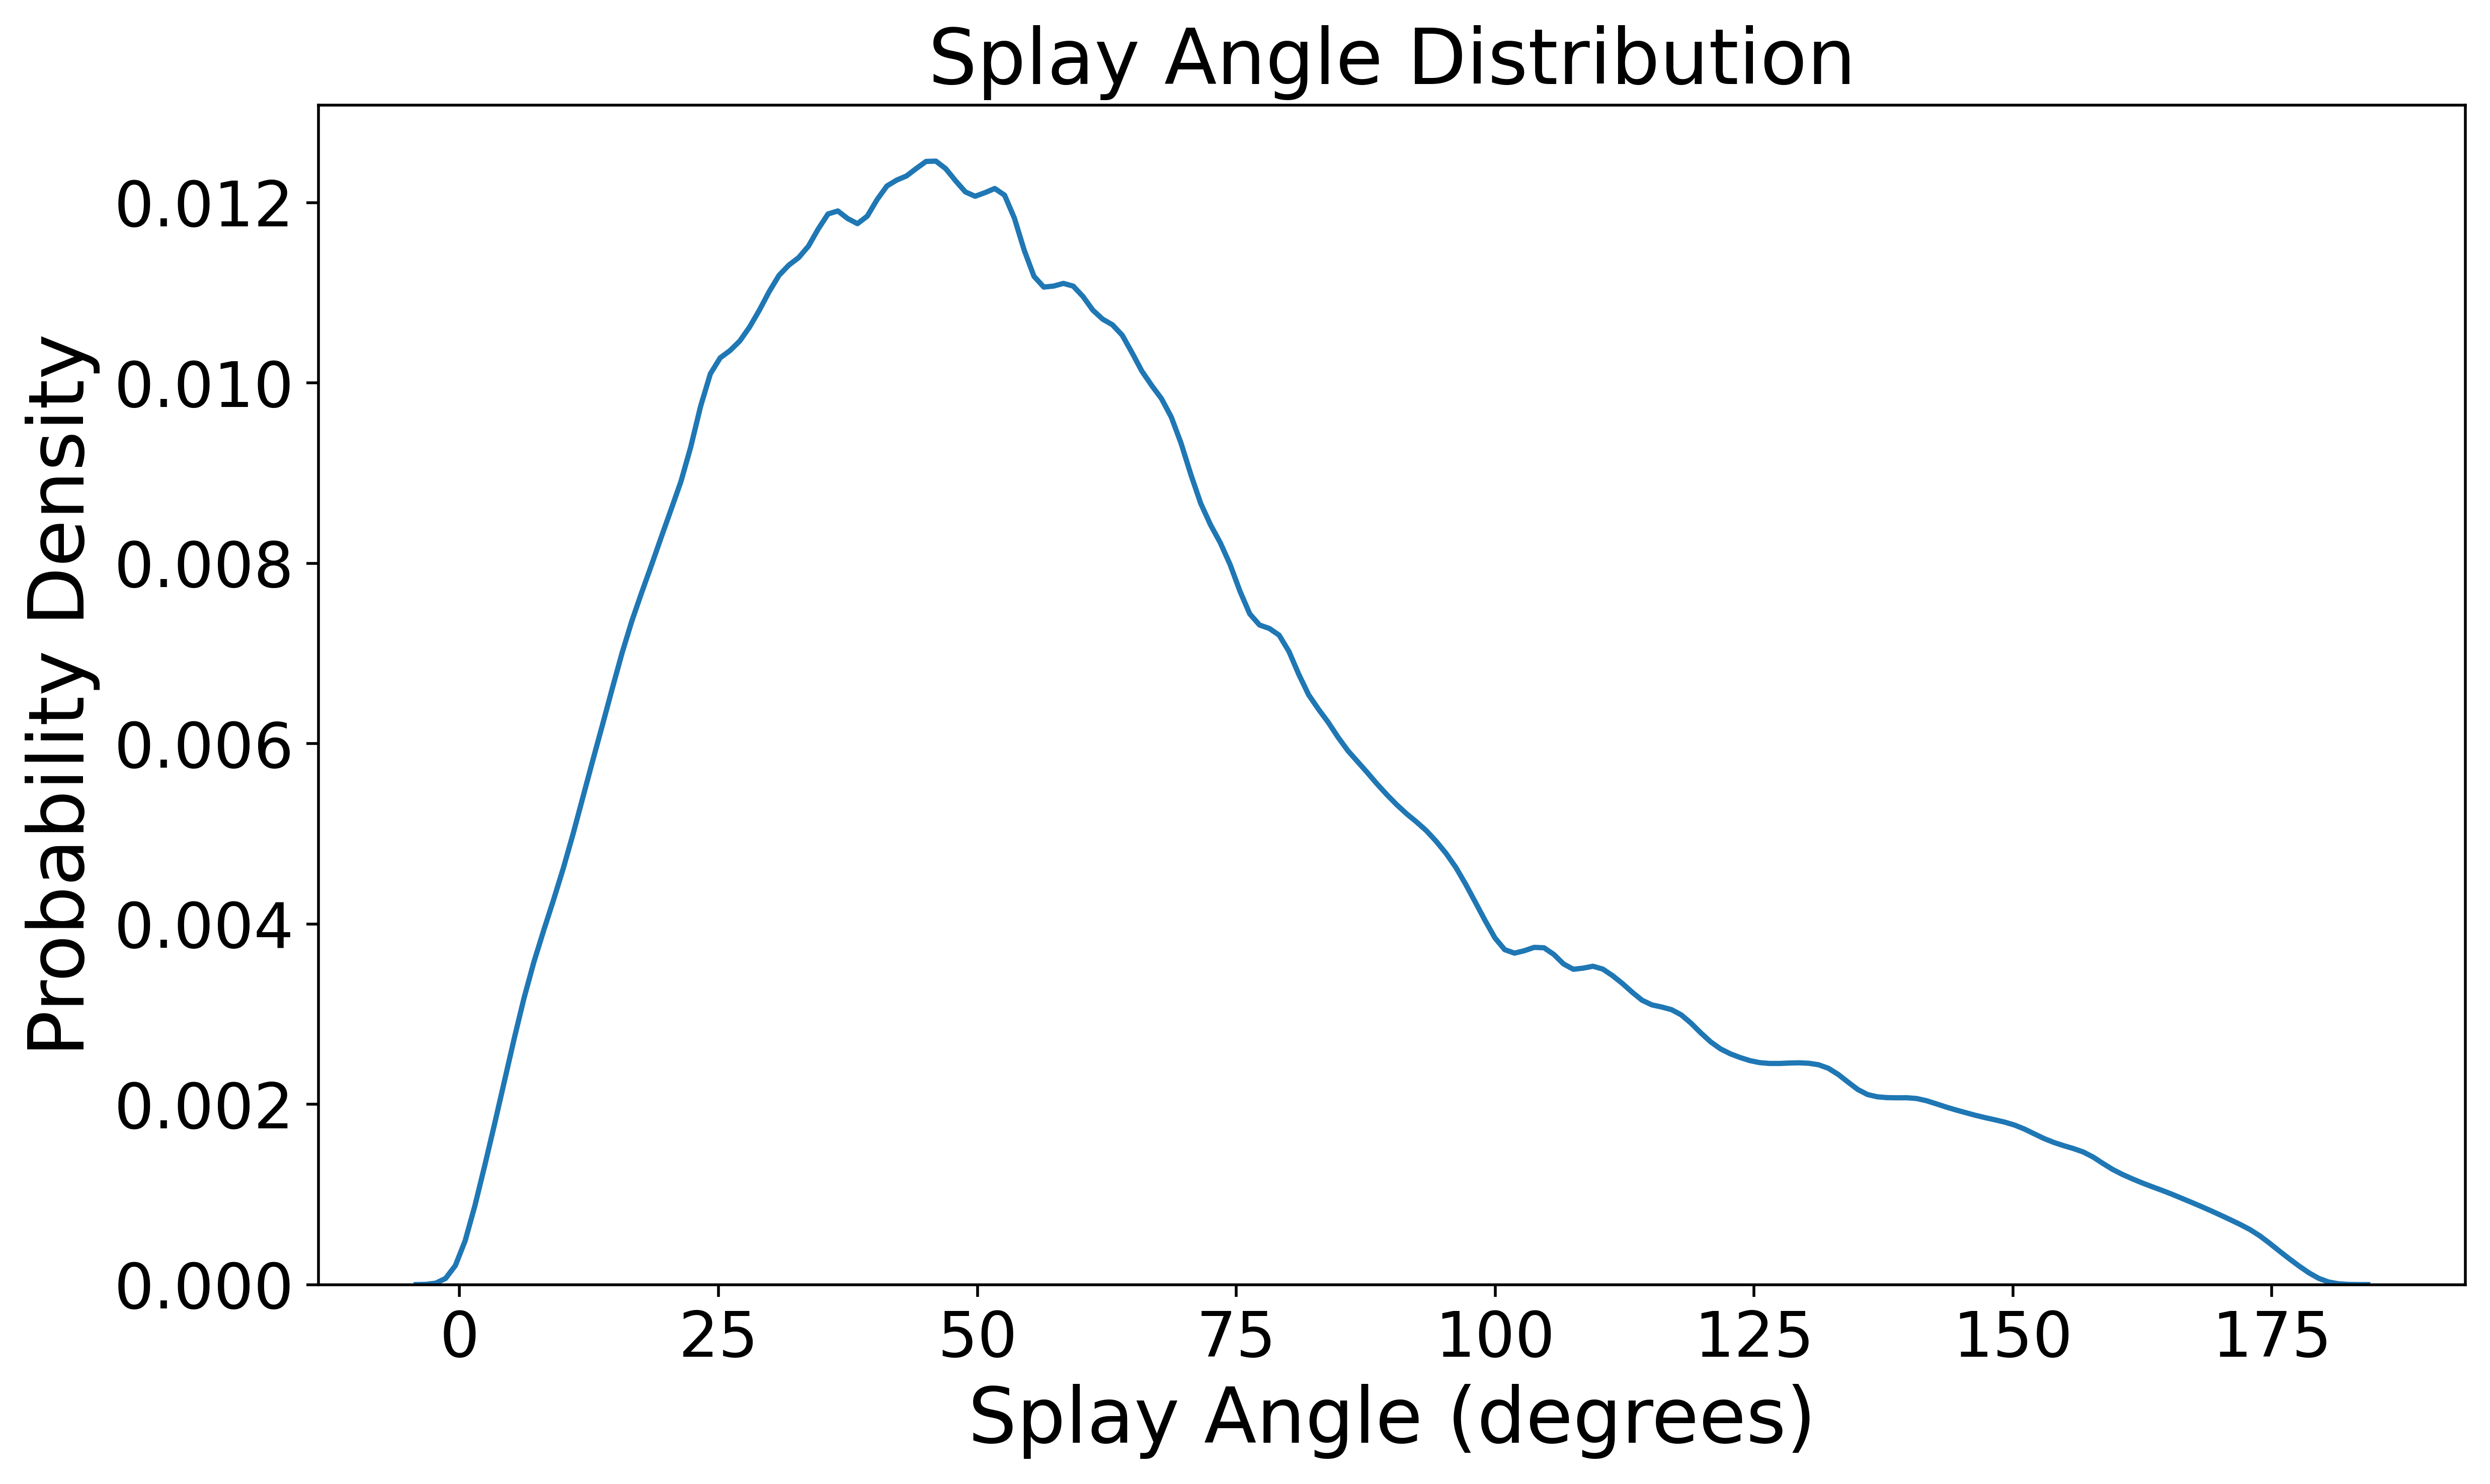

In [78]:
import seaborn as sns
sns.set_palette("tab10")

plt.figure(figsize=(10,6),dpi=500)
sns.kdeplot(splay_angles,linewidth=3) #,kde_kws={'linewidth':3})
plt.xlabel('Splay Angle (degrees)',fontsize=22)
plt.ylabel('Probability Density',fontsize=22)
plt.tick_params(axis = "both",which = "major",labelsize=18)
plt.title('Splay Angle Distribution',fontsize=22)
plt.tight_layout()
plt.show()

<ipython-input-10-8815b1e74140>:14: RuntimeWarning: invalid value encountered in log
  splay_pmf = -kBT * np.log(splay_prob_density / np.sin(np.radians(splay_bins)))


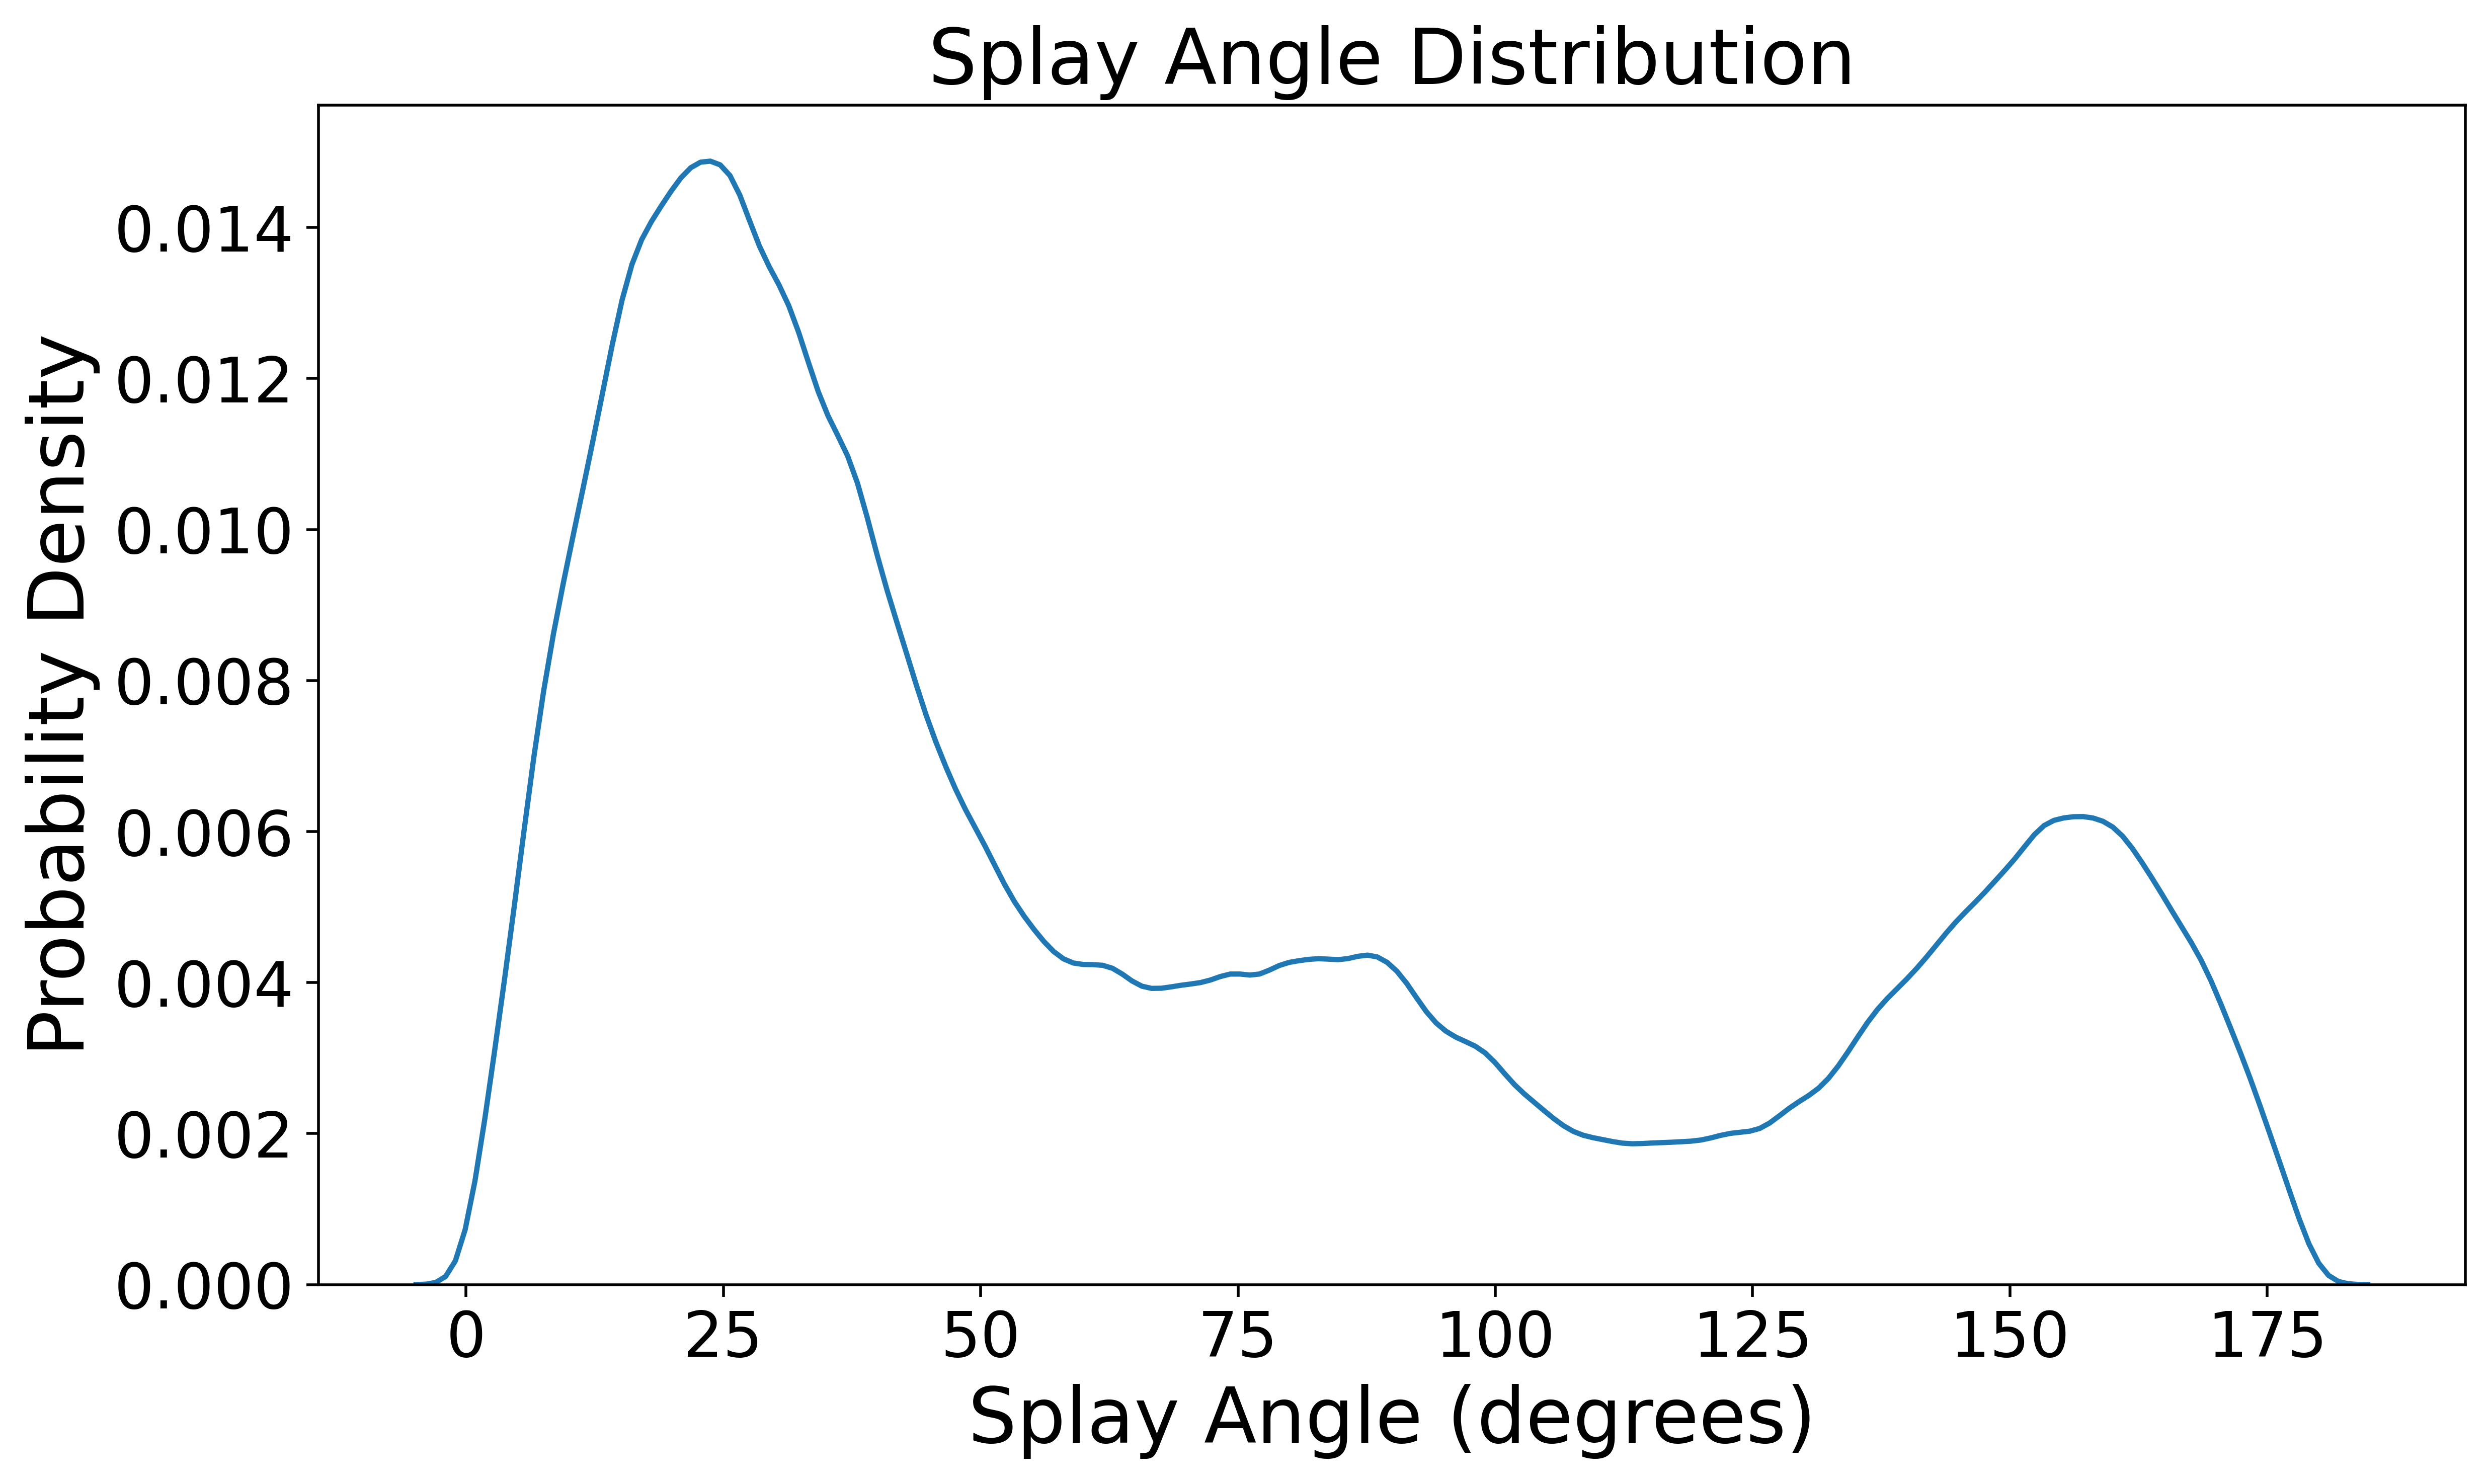

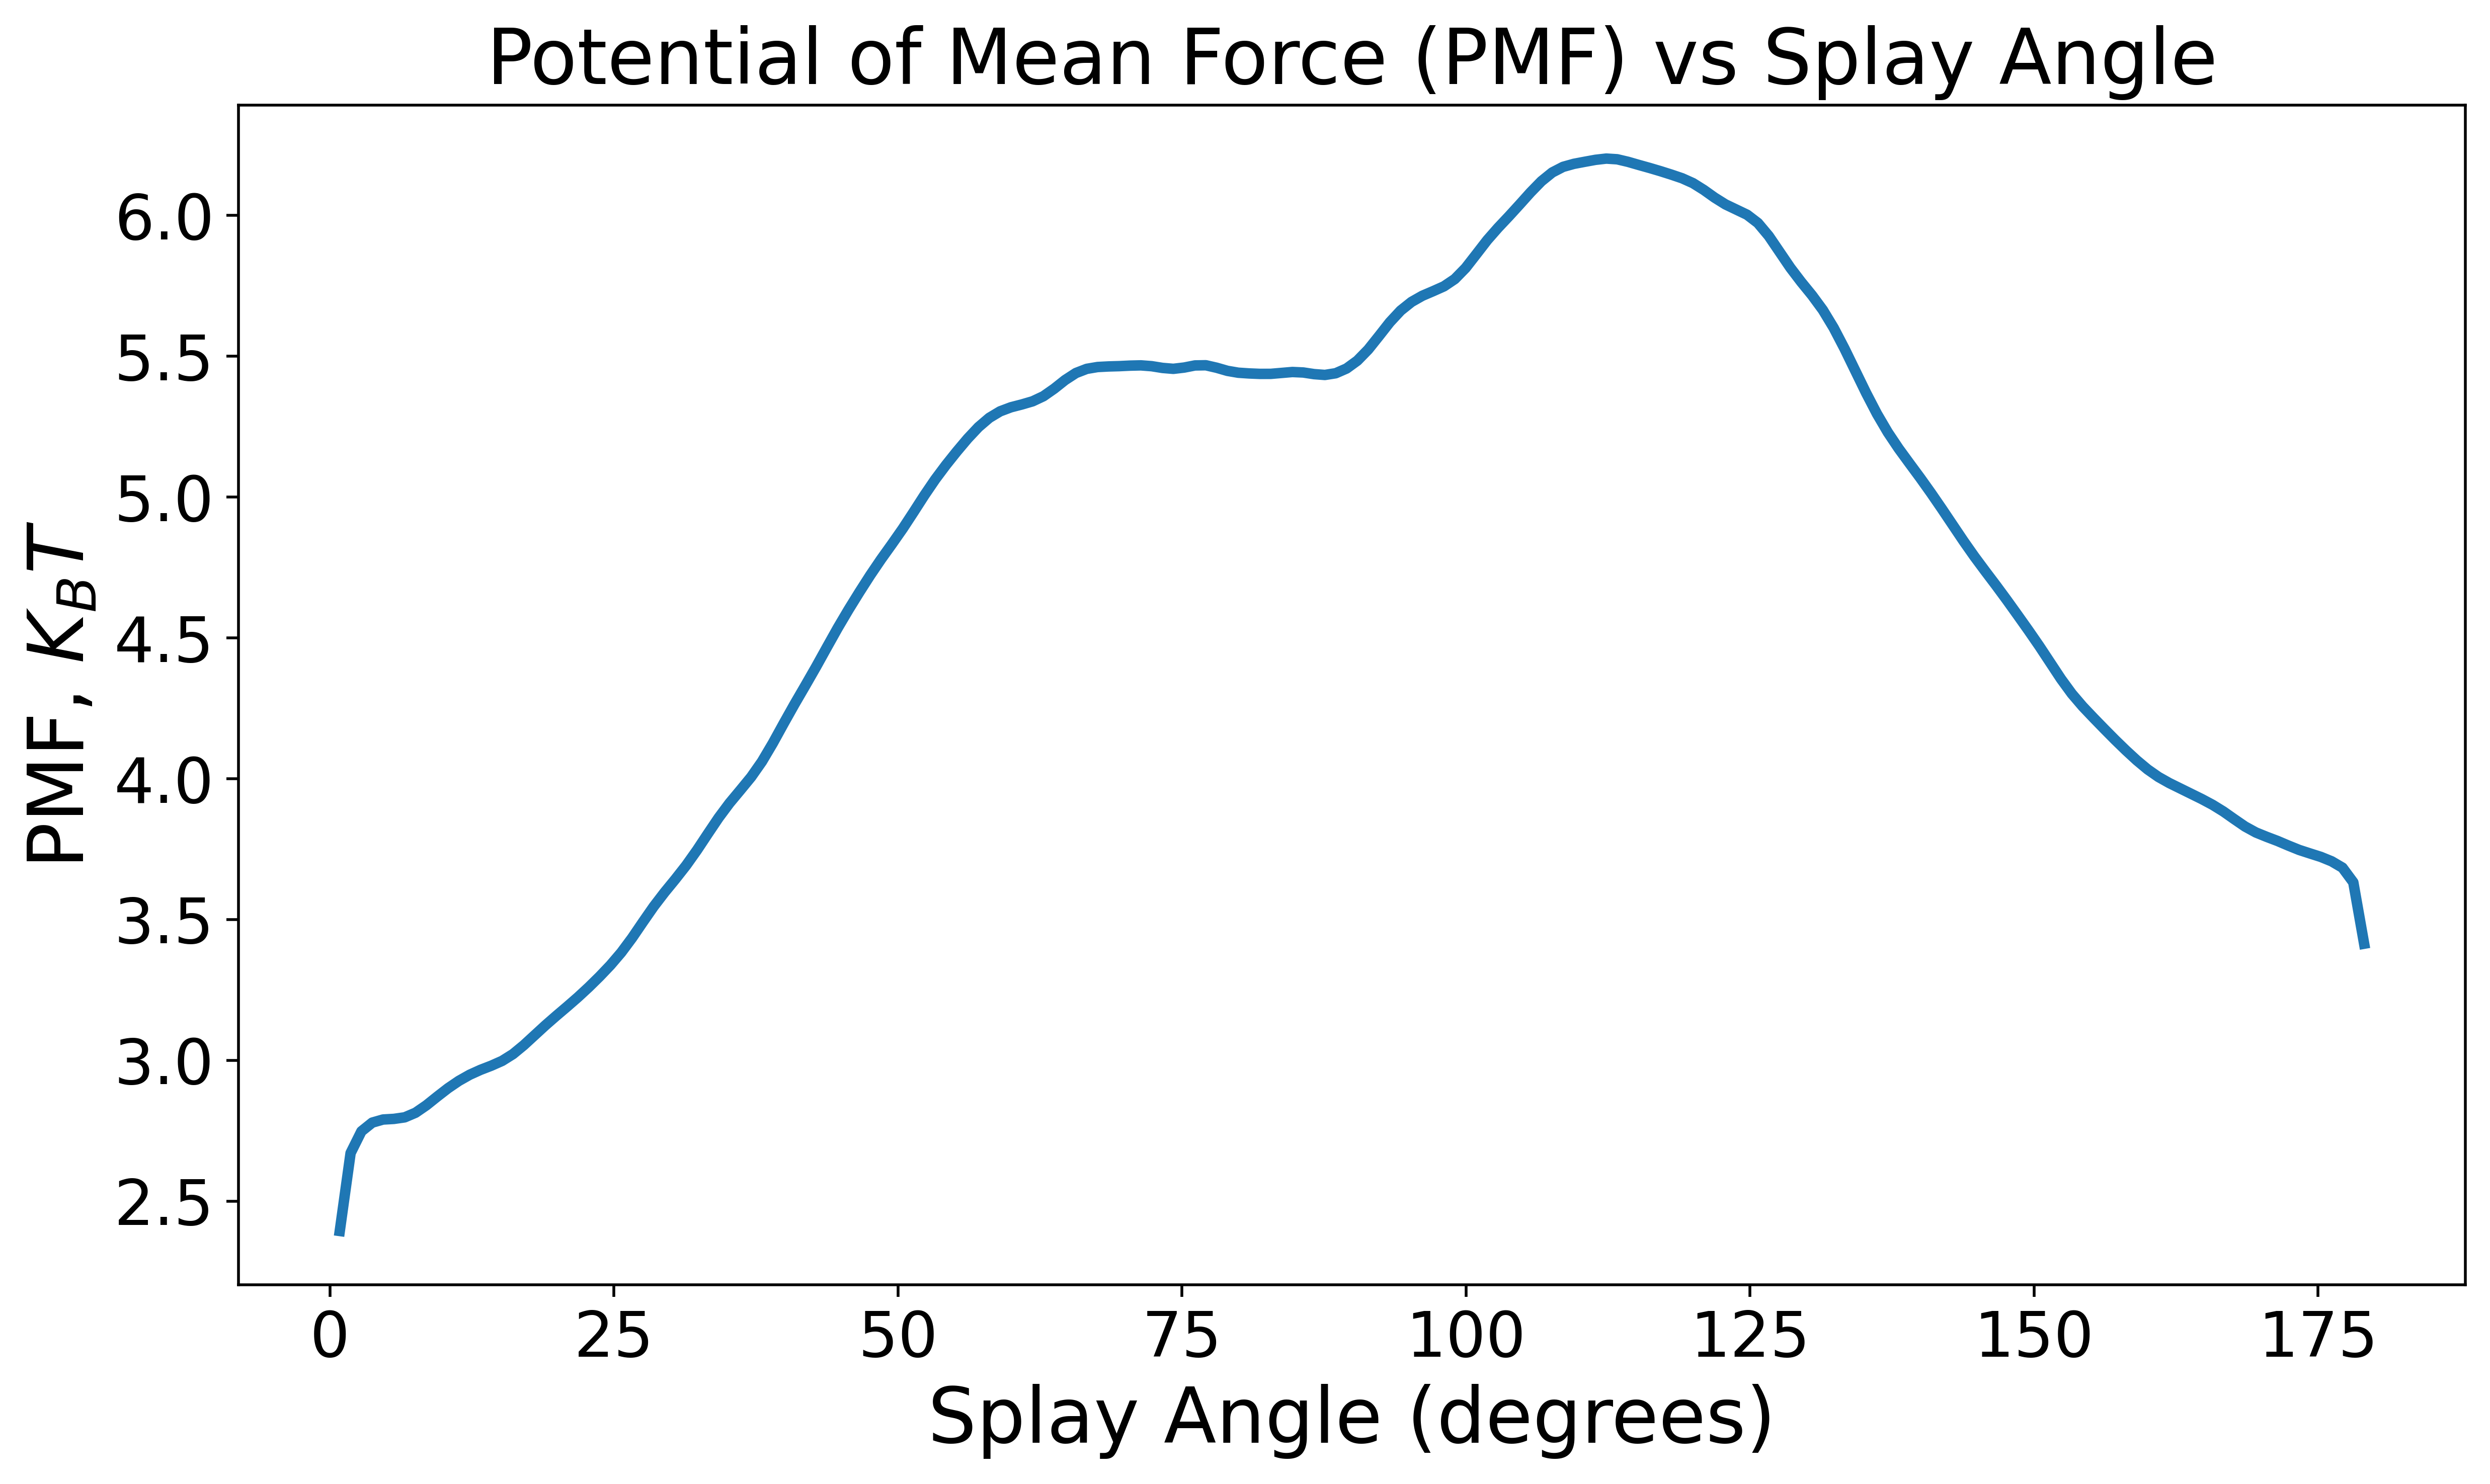

In [10]:
kBT = 1

sns.set_palette("tab10")
plt.figure(figsize=(10,6),dpi=500)
splay_kde = sns.kdeplot(splay_angles, cumulative=False)
plt.xlabel('Splay Angle (degrees)', fontsize=22)
plt.ylabel('Probability Density', fontsize=22)
plt.tick_params(axis="both", which="major", labelsize=18)
plt.title('Splay Angle Distribution', fontsize=22)
plt.tight_layout()

splay_bins = splay_kde.get_lines()[0].get_xdata()
splay_prob_density = splay_kde.get_lines()[0].get_ydata()
splay_pmf = -kBT * np.log(splay_prob_density / np.sin(np.radians(splay_bins)))

plt.figure(figsize=(10,6),dpi=500)
plt.plot(splay_bins, splay_pmf, linewidth=3)
plt.xlabel('Splay Angle (degrees)', fontsize=22)
plt.ylabel('PMF, $K_{B}T$', fontsize=22)
plt.tick_params(axis="both", which="major", labelsize=18)
plt.title('Potential of Mean Force (PMF) vs Splay Angle', fontsize=22)
plt.tight_layout()

plt.show()

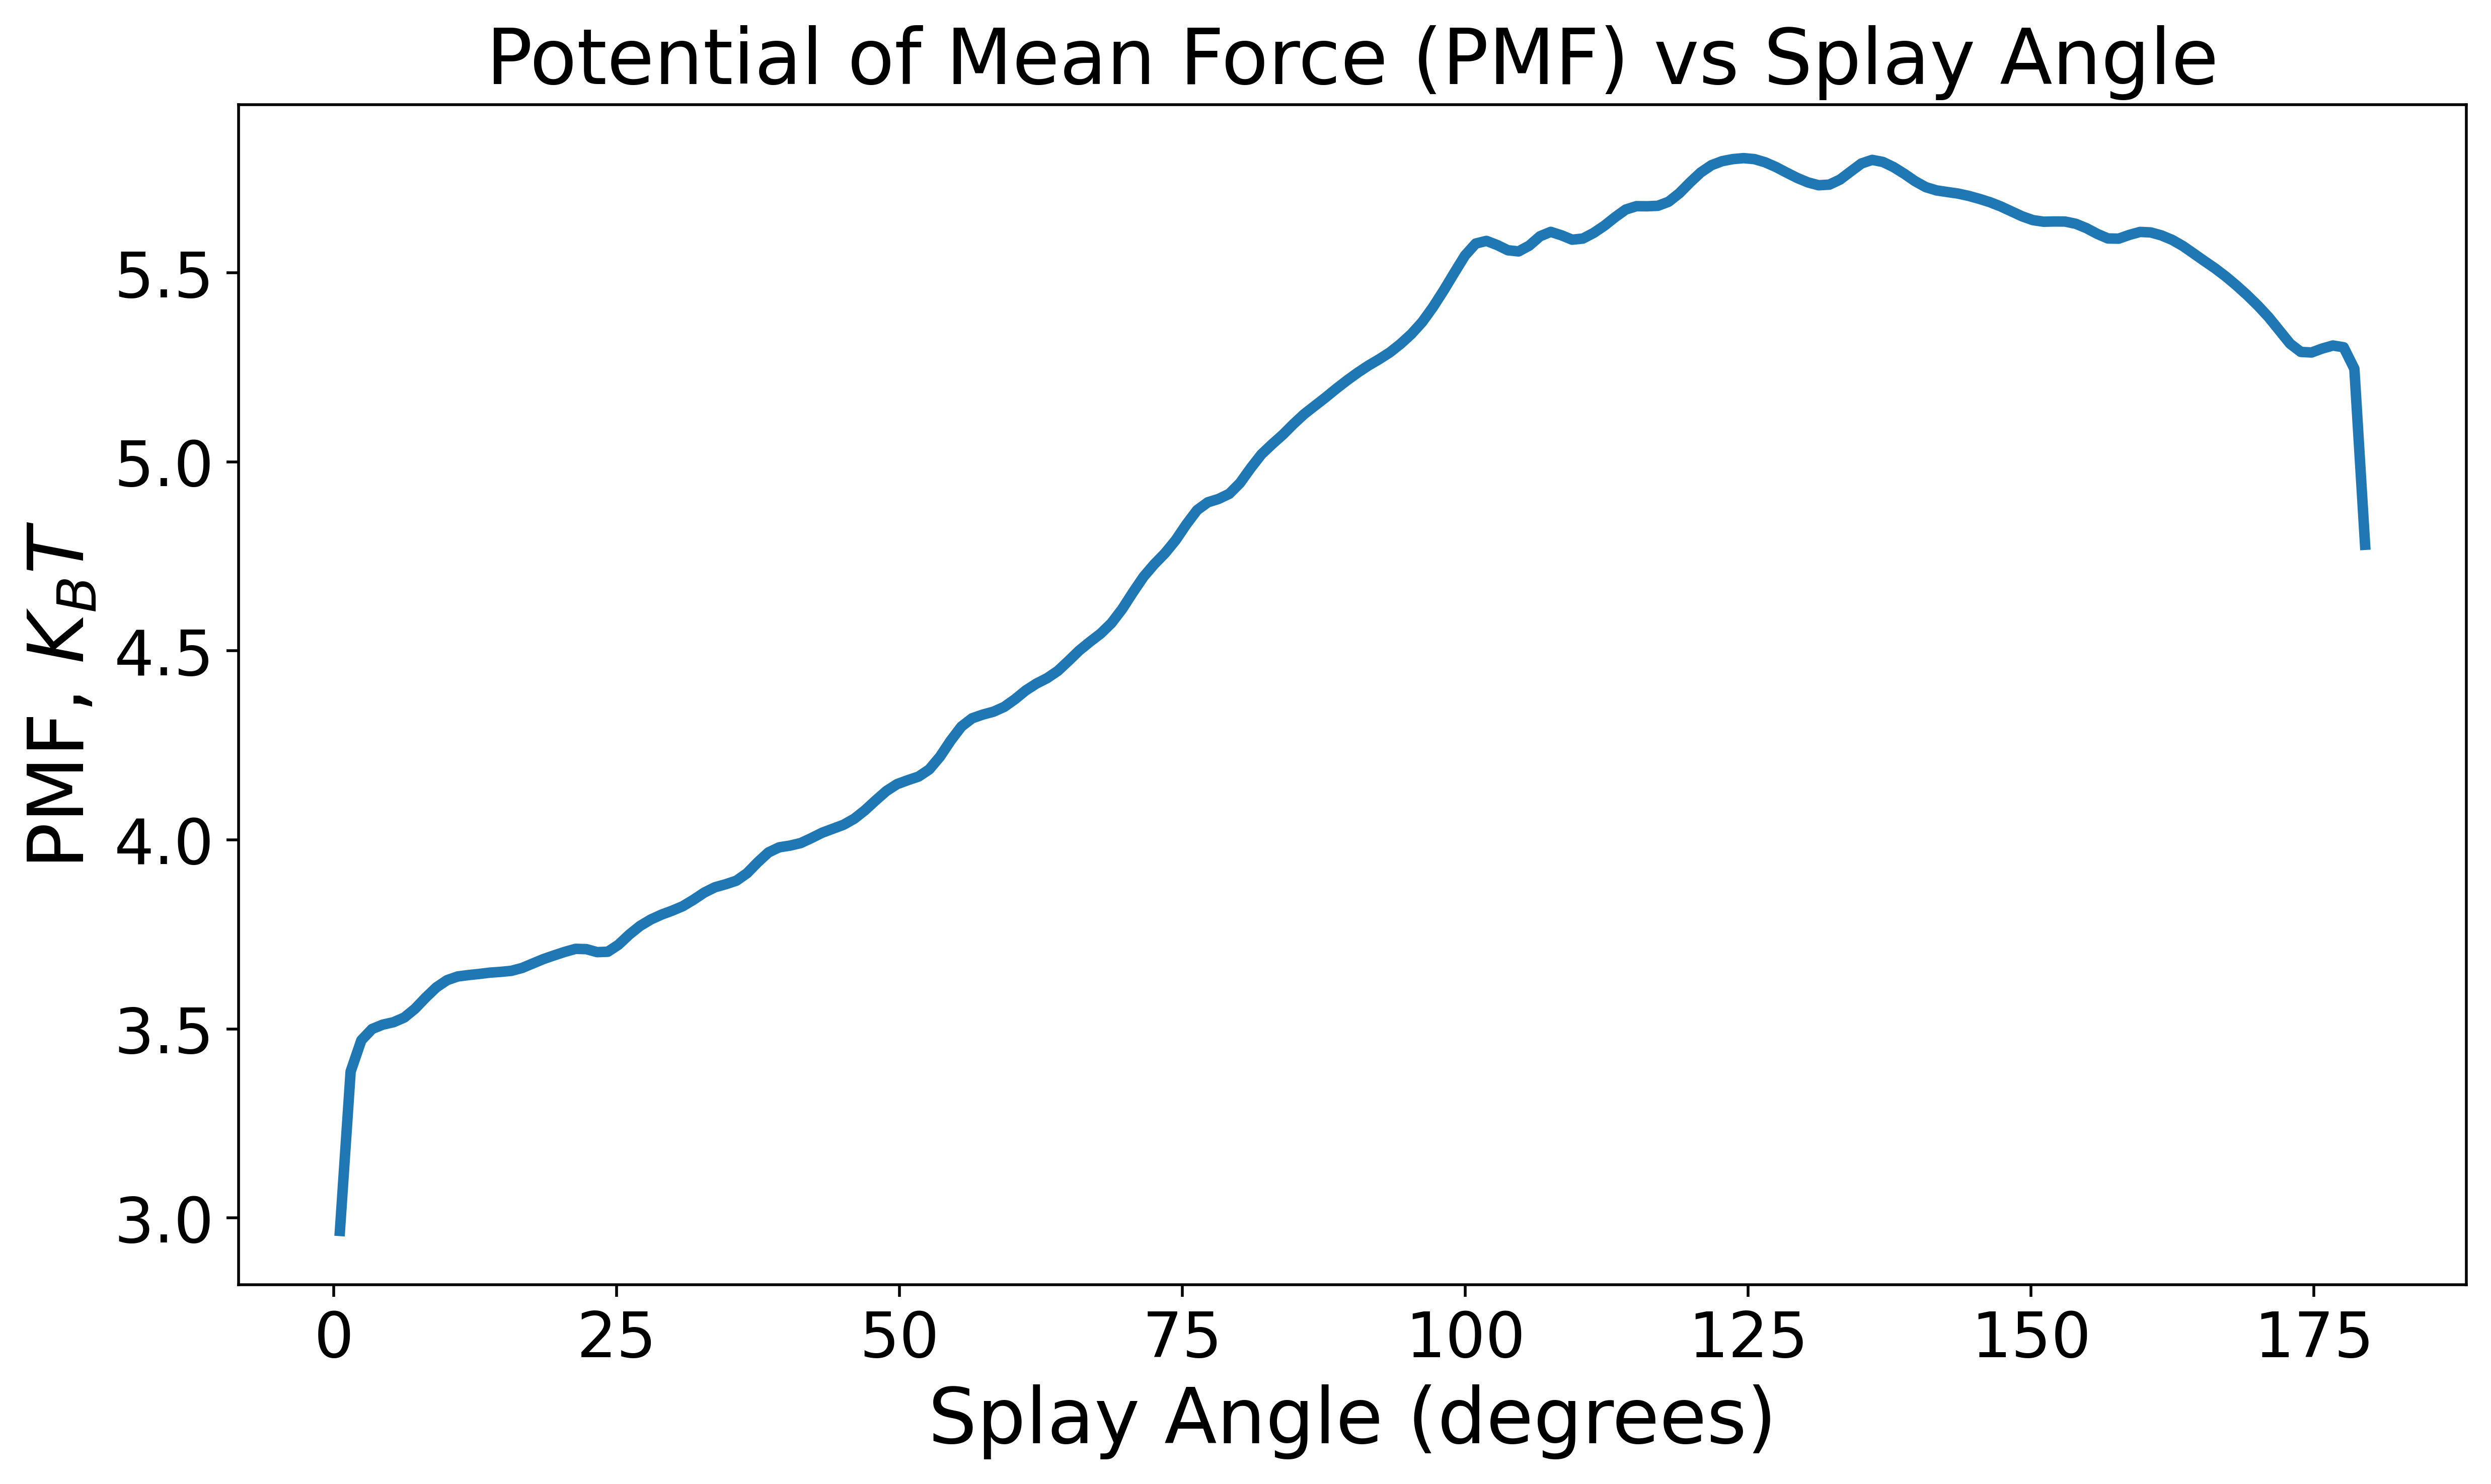

In [75]:
kBT = 1
'''
sns.set_palette("tab10")
plt.figure(figsize=(10,6),dpi=500)
splay_kde = sns.kdeplot(splay_angles, cumulative=False)  
plt.xlabel('Splay Angle (degrees)', fontsize=22)
plt.ylabel('Probability Density', fontsize=22)
plt.tick_params(axis="both", which="major", labelsize=18)
plt.title('Splay Angle Distribution', fontsize=22)
plt.tight_layout()
'''
pmf_nan_mask = ~np.isnan(splay_pmf)
filtered_splay_pmf = splay_pmf[pmf_nan_mask]
filtered_splay_bins = splay_bins[pmf_nan_mask]

df = pd.DataFrame({'Splay Angle (degrees)': filtered_splay_bins, 'PMF': filtered_splay_pmf})

plt.figure(figsize=(10,6),dpi=500)
plt.plot(df[''], filtered_splay_pmf, linewidth=3)
plt.xlabel('Splay Angle (degrees)', fontsize=22)
plt.ylabel('PMF, $K_{B}T$', fontsize=22)
plt.tick_params(axis="both", which="major", labelsize=18)
plt.title('Potential of Mean Force (PMF) vs Splay Angle', fontsize=22)
plt.tight_layout()
plt.show()

In [28]:
splay_pmf_cleaned = splay_pmf[~np.isnan(splay_pmf)]

max_pmf = np.max(splay_pmf_cleaned)
min_pmf = np.min(splay_pmf_cleaned)

print(f"Maximum PMF value: {max_pmf}$K_{B}T$")
print(f"Minimum PMF value: {min_pmf}$K_{B}T$")

Maximum PMF value: 5.803253073764855 kJ/mol
Minimum PMF value: 2.9656547914004268 kJ/mol


In [77]:
print(max(filtered_splay_pmf))

5.803253073886343


     Splay Angle (degrees)       PMF
0                 0.541435  2.965655
1                 1.488451  3.387093
2                 2.435467  3.469850
3                 3.382483  3.499670
4                 4.329499  3.511212
..                     ...       ...
185             175.739396  5.299592
186             176.686412  5.307610
187             177.633428  5.302981
188             178.580444  5.246061
189             179.527460  4.780584

[190 rows x 2 columns]


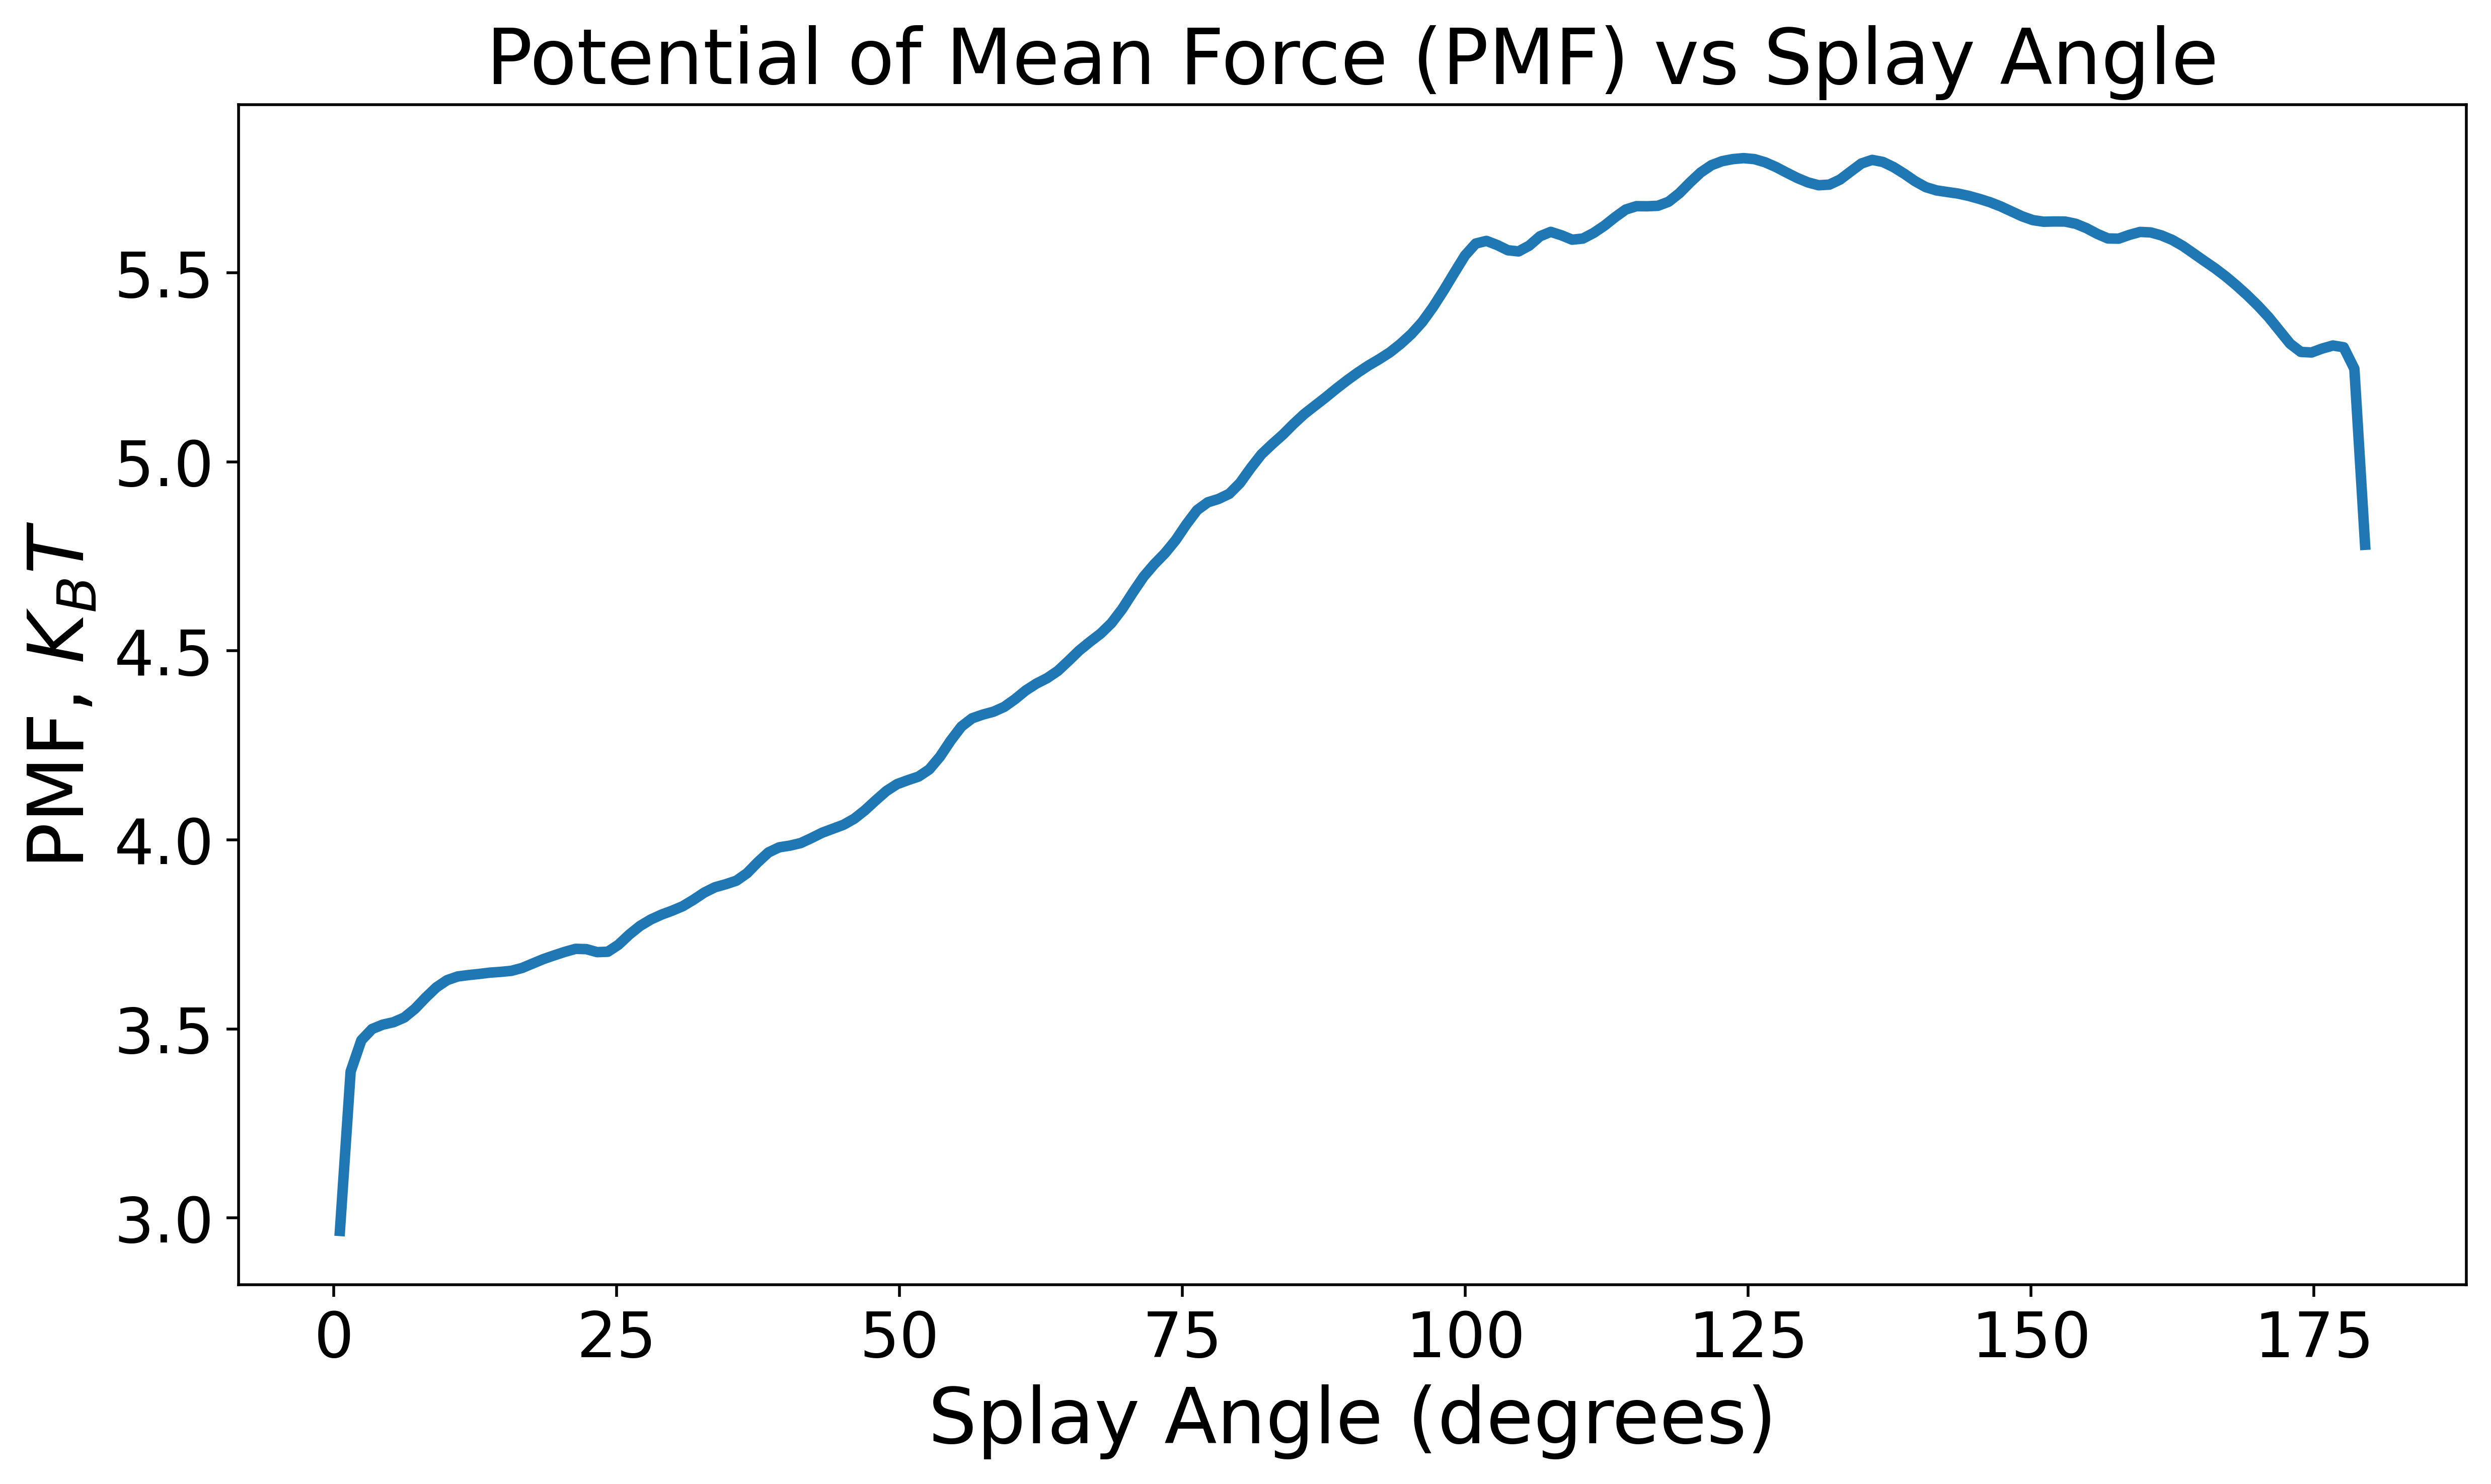

In [97]:
print(df)
plt.figure(figsize=(10,6),dpi=500)
plt.plot(df['Splay Angle (degrees)'], df ['PMF'], linewidth=3)
plt.xlabel('Splay Angle (degrees)', fontsize=22)
plt.ylabel('PMF, $K_{B}T$', fontsize=22)
plt.tick_params(axis="both", which="major", labelsize=18)
plt.title('Potential of Mean Force (PMF) vs Splay Angle', fontsize=22)
plt.tight_layout()
plt.show()

In [107]:
print(PMF)

[2.9656548  3.38709272 3.46985034 3.49967005 3.51121238 3.5176288
 3.52992932 3.55304127 3.58263384 3.60978711 3.62888034 3.63870503
 3.64235854 3.64530808 3.64877769 3.65080104 3.65355197 3.66114089
 3.67289792 3.68474714 3.6944933  3.70382602 3.71172527 3.7109211
 3.70303899 3.70406543 3.72265476 3.74929279 3.77209956 3.78910022
 3.80209839 3.8125424  3.82455524 3.8415944  3.86049722 3.87461191
 3.88254534 3.89193746 3.91185239 3.94086199 3.96688961 3.98030071
 3.98476943 3.99146548 4.00462905 4.01878903 4.02940071 4.0398892
 4.05586729 4.07829399 4.10432815 4.12920614 4.14742186 4.15786132
 4.16733098 4.18627882 4.21993983 4.26243649 4.29966727 4.3215577
 4.33136182 4.33906638 4.35179416 4.37194219 4.39505912 4.41330589
 4.42774291 4.4469247  4.47341359 4.5009075  4.52393347 4.54566695
 4.57324079 4.61030859 4.65420088 4.69596366 4.72911475 4.75819017
 4.79279362 4.8347309  4.87226809 4.89291284 4.90175997 4.91537004
 4.9438569  4.98331903 5.0197711  5.04657338 5.0717518  5.10013072

In [108]:
print(an_array)

[  0.54143546   1.48845146   2.43546746   3.38248346   4.32949947
   5.27651547   6.22353147   7.17054747   8.11756348   9.06457948
  10.01159548  10.95861148  11.90562748  12.85264349  13.79965949
  14.74667549  15.69369149  16.6407075   17.5877235   18.5347395
  19.4817555   20.4287715   21.37578751  22.32280351  23.26981951
  24.21683551  25.16385152  26.11086752  27.05788352  28.00489952
  28.95191553  29.89893153  30.84594753  31.79296353  32.73997953
  33.68699554  34.63401154  35.58102754  36.52804354  37.47505955
  38.42207555  39.36909155  40.31610755  41.26312355  42.21013956
  43.15715556  44.10417156  45.05118756  45.99820357  46.94521957
  47.89223557  48.83925157  49.78626757  50.73328358  51.68029958
  52.62731558  53.57433158  54.52134759  55.46836359  56.41537959
  57.36239559  58.3094116   59.2564276   60.2034436   61.1504596
  62.0974756   63.04449161  63.99150761  64.93852361  65.88553961
  66.83255562  67.77957162  68.72658762  69.67360362  70.62061962
  71.5676356

In [117]:
print(max(PMF))


target = min(PMF)
index = np.argmin(np.abs(PMF - target))
corresponding_x = an_array[index]

print(f"The corresponding x-value for y = {target} is x = {corresponding_x}")

5.803253073886343
The corresponding x-value for y = 2.9656548019827835 is x = 0.5414354572538995


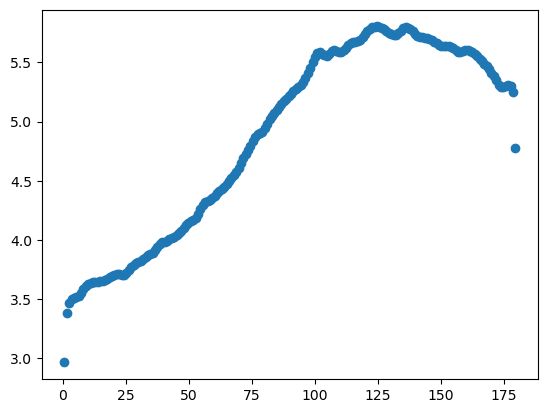

In [100]:
an_array = df['Splay Angle (degrees)'].values
PMF = df['PMF'].values
plt.scatter(an_array,PMF)
plt.show()

In [102]:
def model_f(x,a,b,c):
    return a*(x-b)**2 + c 

In [118]:
popt,pcov = curve_fit(model_f,an_array,PMF,[0.02,2.9656548019827835,0.5414354572538995])

In [119]:
a_opt , b_opt, c_opt = popt
x_model = np.linspace(min(an_array),min(PMF), 100)
y_model = model_f(x_model,a_opt,b_opt,c_opt)

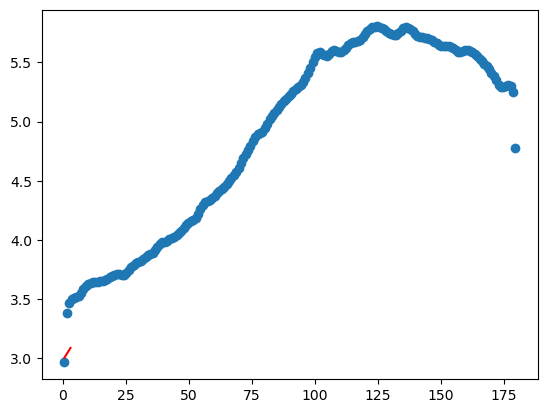

In [121]:
plt.scatter(an_array,PMF)
plt.plot(x_model,y_model,color='r')
plt.show()